<a href="https://colab.research.google.com/github/Teapot-t/kurs-Uczenie-Maszynowe/blob/main/zadanie_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analiza teoretyczna
Zauważmy, że local RSS nie jest równoważne local RSS gain, natomiast toal RSS minimization jest równoważne local RSS gain. Przedstawimy krótki argument.

1.  local RSS minimization, RSS gain maximization

Zauważmy, że dla ustalonego wierzchołka drzewa Parent RSS ze wzoru na RSS gain jest stałą.
$$
   (Parent^*, X_j^*, t^*) = \text{argmax}_{Parent, X_j, t} \Bigl\{
   \underbrace{\sum_{i : x_i \in \text{Parent}} (y_i - \bar{y})^2}_{\text{Parent RSS}}
   \;-\;
   \underbrace{\sum_{m=1}^{2} \sum_{i : x_i \in R_m(X_j, t)} (y_i - \bar{y}_{R_m})^2}_{\text{Children RSS}}
   \Bigr\}.
$$
wtedy $min \{\text{Children RSS}\} = max  \{ - \text{Children RSS}\}$

oraz

$argmin \{\text{Children RSS}\} = argmax \{C_p - \text{Children RSS}\}$

Dla ustalonego wierzchołka zatem podział jest identyczny, więc mogłoby się wydawać, że te dwa kryteria są identyczne. Jednakże stała $C_p$ będąca naszym parent RSS może istotnie wpłynąć na to, który wierzchołek zostanie wybrany do podziału. Jako przykład wyobraźmy sobie drzewo mające dwa liście L i R. niech L ma duży parent RSS - odpowiada obszarowi w którym dane nie są jeszcze dobrze sklasyfikowane. Natomiast R jest obszarem, w którym dane są już dobrze sklasyfikowane i ma bardzo niski parent RSS. Dla ustalenia uwagi i konstrukcji kontrzprzykładu przyjmijmy $\text{parent RSS(L)} = 10$, $\text{parent RSS(L)} = 2$, oraz że optymalny podział obu obszarów generuje łącznie $\text{children RSS(L) = 8}$, $\text{children RSS(R) = 1}$

łatwo sprawdzić, że mniejszy RSS dzieci ma wierzchołek $R$ zatem to on zostanie wybrany do podziału przez local RSS minimization, natomiast podział wierzchołka $L$ generuje większy RSS gain

2. local RSS gain maximization vs total RSS minimization.

te kryteria są równoważne. Niech $T$ oznacza drzewo przed dodaniem nowego podziału, a $T_1$ oznacza drzewo po podziale. Należy zauważyć, że
$$ \text{total RSS}(T_1) = \text{total RSS}(T) - \text{RSS gain} $$
zatem w każdym kroku algorytm wybierze ten sam wierzchołek i podział i wygeneruje identyczne drzewo. istotnie:
$ \text{total RSS}(T_1) = \text{total RSS}(T) - \text{parent RSS} + \text{children RSS} = \text{total RSS}(T) - \text{RSS gain}$


# Analiza zachowania pakietu `sklearn`

przeglądając dokumentację `DecisionTreeRegressor` znajdziemy informację:

"Supported criteria are “squared_error” for the mean squared error, which is equal to variance reduction as feature selection criterion and minimizes the L2 loss using the mean of each terminal node (...)"

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html

co daje nam informację o tym, że pakiet wykorzystuje optymizację RSS ale nie koniecznie doprecyzowuje której wersji sformułowania używa zatem musimy przeprowadzić eksperyment. Postawiłbym hipotezę, że używa algorytmu opartego o RSS gain jako że wydaje się być lepszym narzędziem jak i nie wymaga liczenia RSS każdej wersji drzewa jak total RSS optimization

Przyjmujemy następującą strategię. Tworzymy dwie pary klastrów - L i R. Są mocno oddzielone, a każdy z nich składa się z 2 mniejszych klastrów, które dalej można podzielić. Podzielenie obszaru L na mniejsze da większy RSS gain, natomiast obszaru R mniejszy children RSS (ale nie total RSS). Patrzymy jakie drzewo zostanie skonstruowane i na tej podstawie zobaczymy jak działa badany pakiet

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

np.random.seed(42)

# generujemy obszar L - dwa duże klastry
X_L1 = 0 + np.random.uniform(0, 1, size=(20, 1))
y_L1 = -5 + np.random.normal(0, 1, size=20)

X_L2 = 2 + np.random.uniform(0, 1, size=(20, 1))
y_L2 = 5 + np.random.normal(0, 1, size=20)

# generujemy obszar R - dwa małe klastry
X_R1 = 10 + np.random.uniform(0, 1, size=(20, 1))
y_R1 = 10 + np.random.normal(0, 0.2, size=20)

X_R2 = 12 + np.random.uniform(0, 1, size=(20, 1))
y_R2 = 12 + np.random.normal(0, 0.2, size=20)

# całość - ważne L i R są daleko od siebie - wymuszamy duży podział między L i R w pierwszym kroku (mam nadzieję)
X = np.vstack([X_L1, X_L2, X_R1, X_R2])
y = np.concatenate([y_L1, y_L2, y_R1, y_R2])

In [24]:
tree = DecisionTreeRegressor(max_leaf_nodes=3)
tree.fit(X, y)
thresholds = tree.tree_.threshold
print("Thresholds:", thresholds)

Thresholds: [ 1.50756857 -2.          6.49750197 -2.         -2.        ]


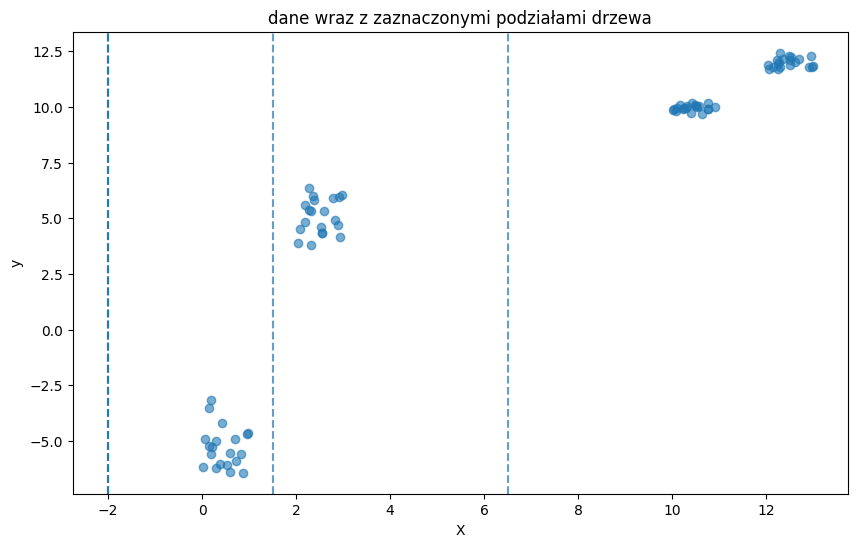

In [28]:
plt.figure(figsize=(10,6))

# dane
plt.scatter(X, y, alpha=0.6)
# linie podziałów przestrzeni X
for t in thresholds:
    plt.axvline(t, linestyle="--", alpha=0.7)

plt.xlabel("X")
plt.ylabel("y")
plt.title("dane wraz z zaznaczonymi podziałami drzewa")
plt.show()

Ręcznie liczymy parametry wybranych obszarów korzystając z ich wcześniejszej konstrukcji


In [26]:
def rss(y):
    return np.sum((y - np.mean(y))**2)

# dla obszaru L - liczymy children RSS i gain
y_L = np.concatenate([y_L1, y_L2])

rss_L = rss(y_L)
children_L = rss(y_L1) + rss(y_L2)
gain_L = rss_L - children_L

# dla obszaru R - liczymy children RSS i gain
y_R = np.concatenate([y_R1, y_R2])

rss_R = rss(y_R)
children_R = rss(y_R1) + rss(y_R2)
gain_R = rss_R - children_R

print("=== L ===")
print("RSS(L):", rss_L)
print("Children RSS(L):", children_L)
print("Gain(L):", gain_L)

print("\n")

print("=== R ===")
print("RSS(R):", rss_R)
print("Children RSS(R):", children_R)
print("Gain(R):", gain_R)

=== L ===
RSS(L): 1102.0067140394099
Children RSS(L): 27.673148779863958
Gain(L): 1074.3335652595458


=== R ===
RSS(R): 42.42630475712137
Children RSS(R): 1.1966457962332462
Gain(R): 41.22965896088812


Jak widać podział przebiegł dokładnie tak jak przewidywaliśmy i sklearn preferuje zwiększyć gain niż podzielić wierzchołek z najmniejszym lokalnym RSS - widać krawędzie decyzyjne na wykresie. (nie wiem jedynie skąd -2 w thresholds pojawia się tyle razy a stąd na wykresie)